In [92]:
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter, ExponentialFitter
from lifelines.utils import k_fold_cross_validation
import pandas as pd
import numpy as np
import seaborn as sns
import warnings

In [93]:
warnings.filterwarnings("ignore")

In [94]:
data_path = 'telco.csv'
r_telco = pd.read_csv(data_path)

In [95]:
def process_data(telco):
    telco = telco.copy()
    telco.drop(['ID'], axis=1, inplace=True)
    categorical_cols = [
        'region', 'retire', 'marital', 'ed',
        'gender', 'voice', 'internet', 'custcat', 'churn', 'forward'
    ]
    telco = pd.get_dummies(telco, columns=categorical_cols, drop_first=True)
    if 'churn_Yes' in telco.columns:
        telco = telco.rename(columns={'churn_Yes': 'churn'})
    telco.dropna(inplace=True)
    
    return telco


In [96]:
telco = process_data(r_telco)
telco

,tenure,age,address,income,region_Zone 2,region_Zone 3,retire_Yes,marital_Unmarried,ed_Did not complete high school,ed_High school degree,ed_Post-undergraduate degree,ed_Some college,gender_Male,voice_Yes,internet_Yes,custcat_E-service,custcat_Plus service,custcat_Total service,churn,forward_Yes
0,13,44,9,64,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
1,11,33,7,136,False,True,False,False,False,False,True,False,True,True,False,False,False,True,True,True
2,68,52,24,116,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False
3,33,33,12,33,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False
4,23,30,9,30,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10,39,0,27,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False
996,7,34,2,22,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
997,67,59,40,944,False,True,False,True,False,False,True,False,False,True,True,False,False,True,False,True
998,70,49,18,87,False,True,False,True,False,True,False,False,False,True,False,False,True,False,False,True


AFT Models

In [97]:
weibull_model = WeibullAFTFitter()
log_logistic_model = LogLogisticAFTFitter()
exponential_model = ExponentialFitter()
log_norm_model = LogNormalAFTFitter()


In [115]:
exponential_model = ExponentialFitter()
exponential = exponential_model.fit(telco['tenure'], event_observed=telco['churn'])
time_range = np.linspace(0, telco['tenure'].max(), 100)
exponential_prediction = exponential.predict(time_range)
exponential_prediction_avg = exponential.survival_function_at_times(time_range)

exponential.print_summary()

<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.98
               hypothesis = lambda_ != 0

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 129.66      7.83          114.30          145.01

         cmp to     z      p  -log2(p)
lambda_    0.00 16.55 <0.005    202.03
---
AIC = 3215.96

In [116]:
weibull = weibull_model.fit(telco, duration_col='tenure', event_col='churn')
weibull_prediction = weibull.predict_survival_function(telco).T
weibull_prediction_avg = weibull_prediction.mean()
weibull.print_summary()

<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.17
         time fit was run = 2025-05-01 17:18:23 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                        
lambda_ address                          0.04      1.04      0.01            0.02            0.06                1.02                1.06
        age                              0.03      1.03      0.01            0.01            0.04                1.01                1.04
        custcat_E-service                0.98      2.66      0.16            0.67            1.28                1.96                3.61
        custcat_Plus service             0.74      2.10      0.19            0.36            1.12                1.44                3.06
        custcat_Total service            1.00      2.71      0.21            0.58            1.41                1.78                4.11
        ed_Did not complete high school  0.44      1.55      0.19            0.06            0.82                1.06                2.27
        ed_High school degree            0.32      1.38      0.15            0.03            0.61                1.03                1.83
        ed_Post-undergraduate degree     0.22      1.25      0.19           -0.15            0.60                0.86                1.82
        ed_Some college                  0.25      1.29      0.14           -0.03            0.54                0.97                1.71
        forward_Yes                     -0.10      0.91      0.15           -0.39            0.19                0.68                1.21
        gender_Male                      0.00      1.00      0.10           -0.20            0.21                0.82                1.23
        income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        internet_Yes                    -0.77      0.46      0.14           -1.04           -0.50                0.35                0.61
        marital_Unmarried               -0.35      0.71      0.10           -0.55           -0.14                0.58                0.87
        region_Zone 2                   -0.06      0.94      0.13           -0.31            0.19                0.73                1.21
        region_Zone 3                    0.12      1.12      0.13           -0.13            0.36                0.87                1.44
        retire_Yes                       0.17      1.19      0.52           -0.85            1.19                0.43                3.30
        voice_Yes                       -0.34      0.72      0.15           -0.63           -0.04                0.53                0.96
        Intercept                        2.78     16.14      0.27            2.25            3.31                9.48               27.47
rho_    Intercept                        0.17      1.19      0.05            0.07            0.27                1.08                1.32

                                         cmp to     z      p  -log2(p)
param   covariate                                                     
lambda_ address                            0.00  4.69 <0.005     18.47
        age                                0.00  4.12 <0.005     14.69
        custcat_E-service                  0.00  6.28 <0.005     31.44
        custcat_Plus service               0.00  3.83 <0.005     12.95
        custcat_Total service              0.00  4.67 <0.005     18.35
        ed_Did not complete high school    0.00  2.25   0.02      5.37
        ed_High school degree              0.00  2.19   0.03    

In [117]:
log_logistic = log_logistic_model.fit(telco, duration_col='tenure', event_col='churn')
log_logistic_prediction = log_logistic.predict_survival_function(telco).T
log_logistic_prediction_avg = log_logistic_prediction.mean()
log_logistic.print_summary()

<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1458.10
         time fit was run = 2025-05-01 17:18:23 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
alpha_ address                          0.04      1.04      0.01            0.02            0.06                1.02                1.06
       age                              0.03      1.03      0.01            0.02            0.05                1.02                1.05
       custcat_E-service                1.04      2.83      0.17            0.72            1.36                2.05                3.91
       custcat_Plus service             0.86      2.37      0.21            0.45            1.27                1.57                3.57
       custcat_Total service            1.20      3.33      0.24            0.73            1.67                2.08                5.34
       ed_Did not complete high school  0.43      1.54      0.20            0.04            0.82                1.05                2.28
       ed_High school degree            0.34      1.40      0.15            0.03            0.64                1.03                1.89
       ed_Post-undergraduate degree    -0.02      0.98      0.22           -0.45            0.40                0.64                1.49
       ed_Some college                  0.24      1.27      0.16           -0.06            0.55                0.94                1.73
       forward_Yes                     -0.19      0.82      0.17           -0.53            0.14                0.59                1.15
       gender_Male                      0.04      1.04      0.11           -0.18            0.26                0.84                1.29
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.80      0.45      0.14           -1.07           -0.52                0.34                0.60
       marital_Unmarried               -0.45      0.64      0.11           -0.66           -0.23                0.52                0.80
       region_Zone 2                   -0.05      0.95      0.14           -0.31            0.22                0.73                1.24
       region_Zone 3                    0.11      1.12      0.14           -0.15            0.38                0.86                1.46
       retire_Yes                       0.06      1.06      0.48           -0.87            1.00                0.42                2.71
       voice_Yes                       -0.40      0.67      0.16           -0.72           -0.08                0.49                0.92
       Intercept                        2.33     10.33      0.28            1.78            2.89                5.95               17.93
beta_  Intercept                        0.34      1.40      0.05            0.24            0.44                1.27                1.55

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
alpha_ address                            0.00  4.42 <0.005     16.60
       age                                0.00  4.67 <0.005     18.36
       custcat_E-service                  0.00  6.30 <0.005     31.62
       custcat_Plus service               0.00  4.13 <0.005     14.74
       custcat_Total service              0.00  5.00 <0.005     20.73
       ed_Did not complete high school    0.00  2.18   0.03      5.11
       ed_High school degree              0.00  2.17   0.03      5.04
       ed_Post-under

In [118]:
log_norm = log_norm_model.fit(telco, duration_col='tenure', event_col='churn')
log_norm_prediction = log_norm.predict_survival_function(telco).T
log_norm_prediction_avg = log_norm_prediction.mean()
log_norm.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1457.01
         time fit was run = 2025-05-01 17:18:23 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
mu_    address                          0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                              0.03      1.03      0.01            0.02            0.05                1.02                1.05
       custcat_E-service                1.07      2.90      0.17            0.73            1.40                2.08                4.06
       custcat_Plus service             0.92      2.52      0.22            0.50            1.35                1.65                3.85
       custcat_Total service            1.20      3.32      0.25            0.71            1.69                2.03                5.42
       ed_Did not complete high school  0.37      1.45      0.20           -0.02            0.77                0.98                2.16
       ed_High school degree            0.32      1.37      0.16           -0.00            0.64                1.00                1.89
       ed_Post-undergraduate degree    -0.03      0.97      0.22           -0.47            0.40                0.62                1.50
       ed_Some college                  0.27      1.31      0.17           -0.05            0.60                0.95                1.82
       forward_Yes                     -0.20      0.82      0.18           -0.55            0.15                0.58                1.17
       gender_Male                      0.05      1.05      0.11           -0.17            0.28                0.84                1.32
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.77      0.46      0.14           -1.05           -0.49                0.35                0.61
       marital_Unmarried               -0.46      0.63      0.12           -0.68           -0.23                0.51                0.80
       region_Zone 2                   -0.10      0.91      0.14           -0.38            0.18                0.69                1.20
       region_Zone 3                    0.05      1.05      0.14           -0.23            0.33                0.80                1.38
       retire_Yes                       0.02      1.02      0.44           -0.85            0.89                0.43                2.44
       voice_Yes                       -0.43      0.65      0.17           -0.76           -0.10                0.47                0.90
       Intercept                        2.36     10.61      0.29            1.79            2.94                5.98               18.84
sigma_ Intercept                        0.28      1.32      0.05            0.19            0.37                1.20                1.44

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
mu_    address                            0.00  4.78 <0.005     19.11
       age                                0.00  4.50 <0.005     17.19
       custcat_E-service                  0.00  6.25 <0.005     31.21
       custcat_Plus service               0.00  4.29 <0.005     15.75
       custcat_Total service              0.00  4.79 <0.005     19.16
       ed_Did not complete high school    0.00  1.85   0.06      3.97
       ed_High school degree              0.00  1.94   0.05      4.24
       ed_Post-undergr

In [119]:
print(f'Weibull AIC: {weibull.AIC_}')
print(f'Exponential AIC: {exponential.AIC_}')
print(f'Log-Normal AIC: {log_norm.AIC_}')
print(f'Log-Logistic AIC: {log_logistic.AIC_}')
scores = {'Exponential': exponential.AIC_, 'Log-normal': log_norm.AIC_, 'Log-logistic': log_logistic.AIC_, 'Weibull': weibull.AIC_}
print(f'\nThe best model based on AIC scores is: \033[1m{min(scores, key=scores.get)}\033[0m')

Weibull AIC: 2964.3432480838806
Exponential AIC: 3215.9608134637247
Log-Normal AIC: 2954.0240102517123
Log-Logistic AIC: 2956.2085614433336

The best model based on AIC scores is: Log-normal


Beyond relying solely on the AIC score and visual plots, there are several key factors to consider when selecting the most appropriate model. One such factor is model complexity, which is determined by the number of parameters each model contains. For example, the Log-Normal and Log-Logistic models each include three parameters, the Weibull model includes two, and the Exponential model is the simplest with only one. As a result, the Exponential model is the least complex of the four.

Another important consideration is the hazard rate behavior. When the data suggests a non-constant hazard rate, the Weibull model is often preferred over the Exponential model due to its flexibility in capturing both increasing and decreasing hazard rates.

That said, if the goal is to identify the best-fitting model based on statistical performance, the AIC score remains the primary criterion. According to this measure, the Log-Normal model emerges as the optimal choice.

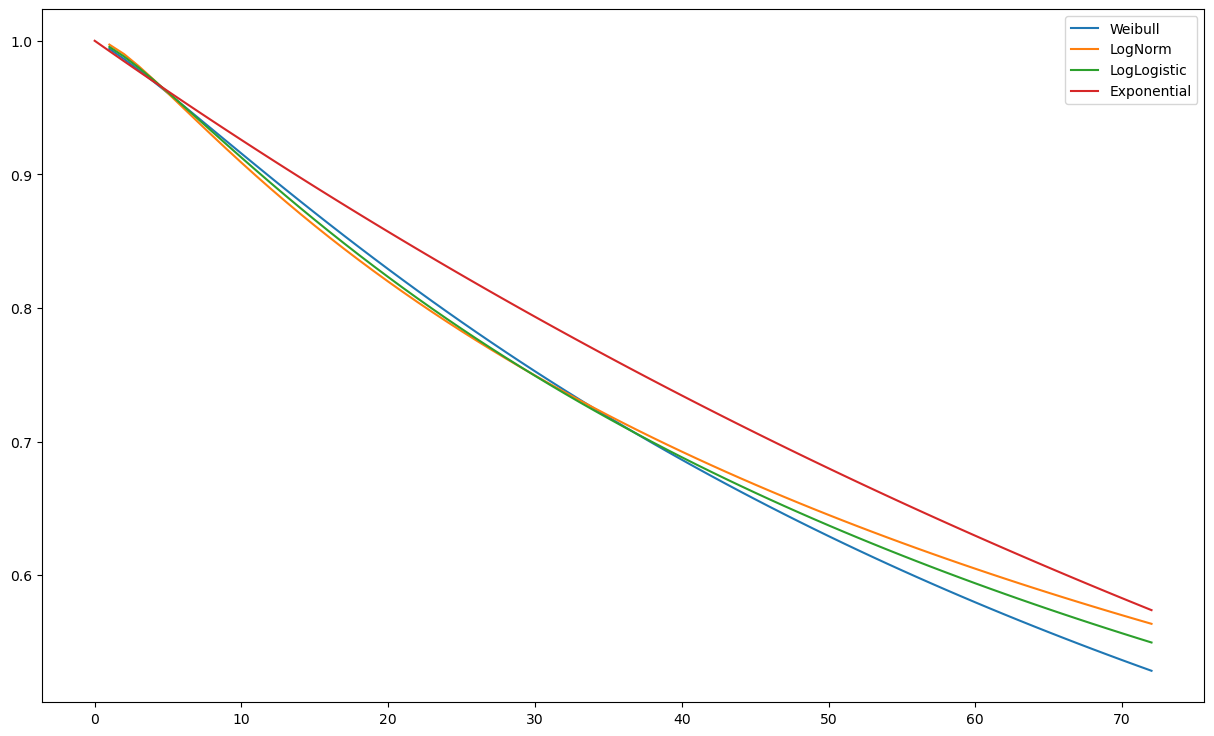

In [120]:
plt.figure(figsize=(15,9))
plt.plot(weibull_prediction_avg, label='Weibull')
plt.plot(log_norm_prediction_avg, label='LogNorm')
plt.plot(log_logistic_prediction_avg, label='LogLogistic')
plt.plot(exponential_prediction_avg, label='Exponential')
plt.legend()
plt.show()

In [52]:
sign_columns = ["address", "age", "internet_Yes", "marital_Unmarried", "tenure", "churn", "custcat_E-service", "custcat_Plus service", "custcat_Total service", "voice_Yes"]

In [53]:
d_telco = telco[sign_columns]
d_telco

,address,age,internet_Yes,marital_Unmarried,tenure,churn,custcat_E-service,custcat_Plus service,custcat_Total service,voice_Yes
0,9,44,False,False,13,True,False,False,False,False
1,7,33,False,False,11,True,False,False,True,True
2,24,52,False,False,68,False,False,True,False,False
3,12,33,False,True,33,True,False,False,False,False
4,9,30,False,False,23,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
995,0,39,False,True,10,False,False,False,False,False
996,2,34,False,True,7,False,False,False,False,False
997,40,59,True,True,67,False,False,False,True,True
998,18,49,False,True,70,False,False,True,False,True


In [54]:
log_norm = log_norm_model.fit(d_telco, duration_col='tenure', event_col='churn')
log_norm_prediction = log_norm.predict_survival_function(d_telco).T
log_norm_prediction_avg = log_norm_prediction.mean()
log_norm.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.10
         time fit was run = 2025-05-01 16:58:32 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      1.03      2.79      0.17            0.69            1.36                2.00                3.89
       custcat_Plus service   0.82      2.28      0.17            0.49            1.15                1.63                3.17
       custcat_Total service  1.01      2.75      0.21            0.60            1.42                1.83                4.15
       internet_Yes          -0.84      0.43      0.14           -1.11           -0.57                0.33                0.57
       marital_Unmarried     -0.45      0.64      0.11           -0.67           -0.22                0.51                0.80
       voice_Yes             -0.46      0.63      0.17           -0.79           -0.14                0.45                0.87
       Intercept              2.53     12.62      0.24            2.06            3.01                7.84               20.30
sigma_ Intercept              0.28      1.33      0.05            0.19            0.37                1.21                1.45

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  4.84 <0.005     19.56
       age                      0.00  5.75 <0.005     26.78
       custcat_E-service        0.00  6.07 <0.005     29.53
       custcat_Plus service     0.00  4.85 <0.005     19.66
       custcat_Total service    0.00  4.83 <0.005     19.52
       internet_Yes             0.00 -6.08 <0.005     29.63
       marital_Unmarried        0.00 -3.91 <0.005     13.39
       voice_Yes                0.00 -2.78   0.01      7.52
       Intercept                0.00 10.45 <0.005     82.47
sigma_ Intercept                0.00  6.15 <0.005     30.27
---
Concordance = 0.79
AIC = 2944.20
log-likelihood ratio test = 280.83 on 8 df
-log2(p) of ll-ratio test = 183.73

CLV

In [55]:
clv_telco = log_norm_prediction.copy()

In [56]:
margin = 1000
sequence = range(1,len(clv_telco.columns)+1)
r = 0.1

In [57]:
for i in sequence:
    clv_telco.loc[:, i] = clv_telco.loc[:, i]/((1+r/12)**(sequence[i-1]-1))

In [58]:
clv_telco["CLV"] = margin * clv_telco.sum(axis = 1)
clv_telco

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0,CLV
0,0.999688,0.989880,0.978868,0.966893,0.954194,0.940967,0.927370,0.913526,0.899533,0.885469,...,0.363526,0.357889,0.352351,0.346911,0.341567,0.336317,0.331159,0.326092,0.321112,43421.920852
1,0.999736,0.990127,0.979439,0.967868,0.955620,0.942870,0.929761,0.916405,0.902892,0.889296,...,0.373555,0.367869,0.362283,0.356792,0.351396,0.346093,0.340880,0.335756,0.330720,44012.968135
2,0.999999,0.991724,0.983496,0.975307,0.967152,0.959028,0.950934,0.942869,0.934834,0.926828,...,0.561230,0.555839,0.550497,0.545202,0.539956,0.534757,0.529605,0.524500,0.519441,53279.464095
3,0.997985,0.982516,0.963596,0.942708,0.920782,0.898406,0.875956,0.853676,0.831726,0.810209,...,0.236111,0.231513,0.227024,0.222639,0.218356,0.214171,0.210084,0.206089,0.202185,34882.879434
4,0.999870,0.990870,0.981213,0.970970,0.960245,0.949137,0.937733,0.926110,0.914328,0.902440,...,0.413868,0.408046,0.402314,0.396671,0.391115,0.385646,0.380260,0.374959,0.369738,46287.751605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.996036,0.975404,0.950272,0.923094,0.895196,0.867318,0.839884,0.813132,0.787198,0.762150,...,0.187415,0.183429,0.179547,0.175765,0.172079,0.168488,0.164988,0.161575,0.158249,30970.665732
996,0.995073,0.972135,0.944405,0.914717,0.884526,0.854605,0.825374,0.797056,0.769766,0.743549,...,0.172052,0.168286,0.164620,0.161053,0.157579,0.154197,0.150903,0.147695,0.144569,29633.260935
997,0.999991,0.991651,0.983268,0.974822,0.966311,0.957738,0.949110,0.940436,0.931725,0.922986,...,0.518455,0.512743,0.507093,0.501505,0.495977,0.490511,0.485104,0.479757,0.474468,51473.533992
998,0.999923,0.991186,0.982008,0.972409,0.962449,0.952190,0.941692,0.931008,0.920183,0.909257,...,0.440037,0.434174,0.428396,0.422700,0.417087,0.411554,0.406100,0.400725,0.395427,47681.088097


In [59]:
r_telco["CLV"] = clv_telco.CLV

Customers with higher CLV have higher probability of staying in the company

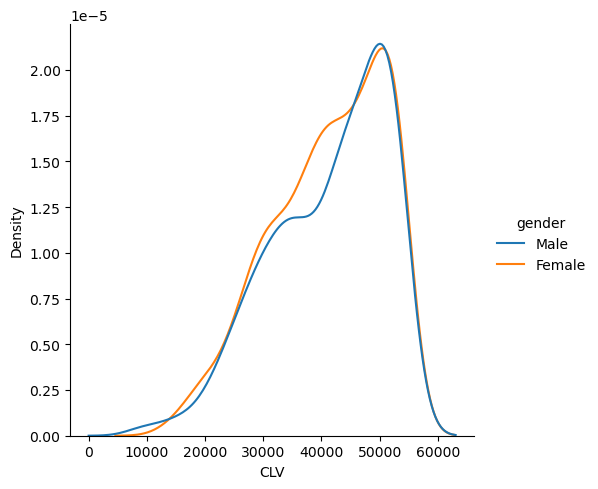

In [60]:
sns.displot(data = r_telco, kind='kde', x='CLV', hue='gender')

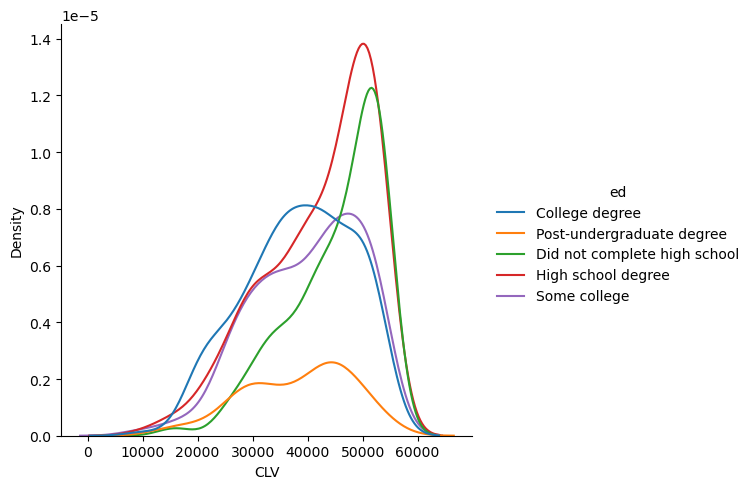

In [61]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='ed')

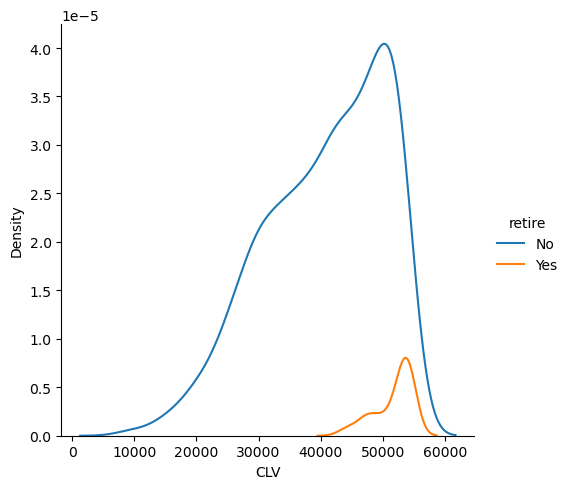

In [62]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='retire')

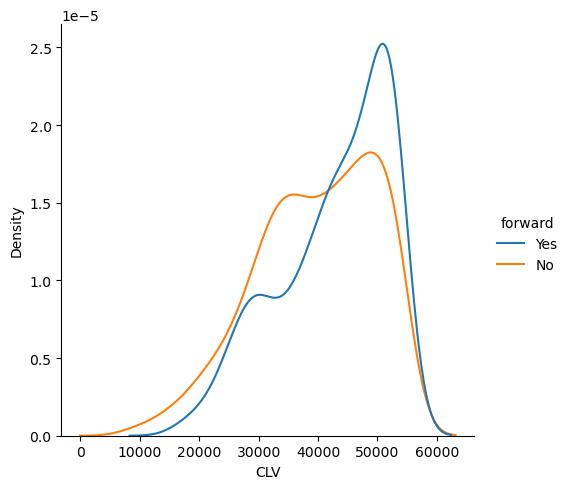

In [63]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='forward')

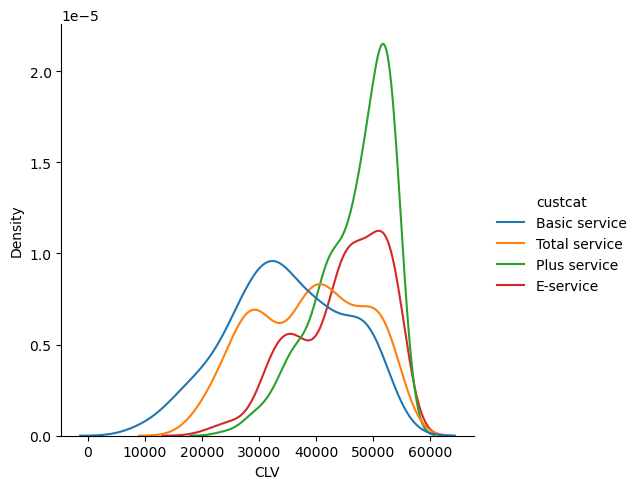

In [64]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='custcat')

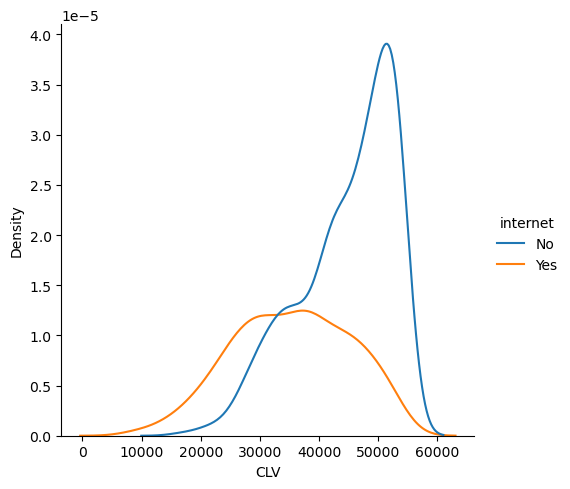

In [65]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='internet')

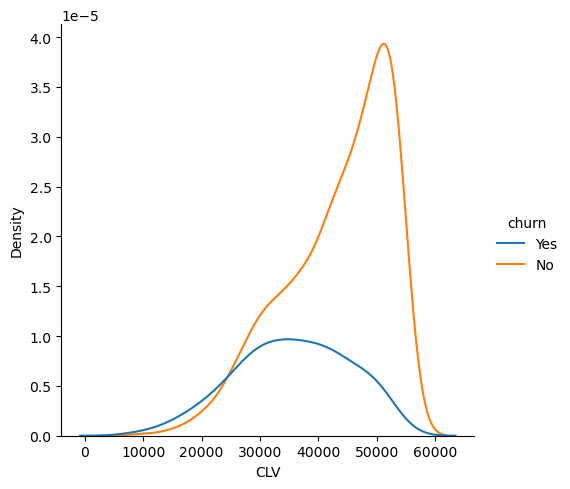

In [66]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='churn')

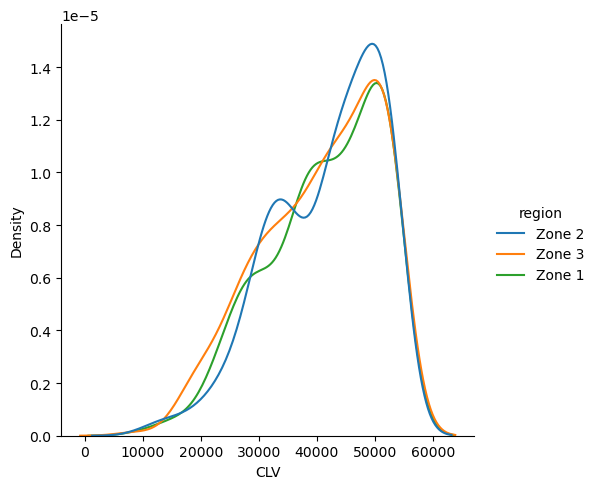

In [67]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='region')

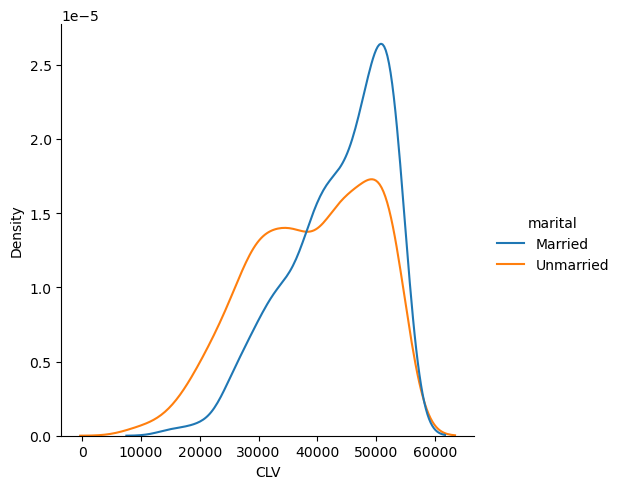

In [68]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='marital')

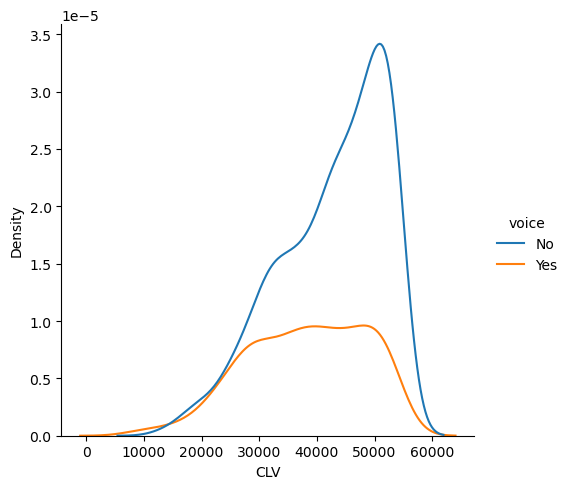

In [69]:
sns.displot(data=r_telco, kind='kde', x='CLV', hue='voice')

In [70]:
print(r_telco.groupby("gender")[["CLV"]].mean())
print(r_telco.groupby("forward")[["CLV"]].mean())
print(r_telco.groupby("voice")[["CLV"]].mean())
print(r_telco.groupby("marital")[["CLV"]].mean())
print(r_telco.groupby("region")[["CLV"]].mean())

print(r_telco.groupby("internet")[["CLV"]].mean())
print(r_telco.groupby("custcat")[["CLV"]].mean())
print(r_telco.groupby("retire")[["CLV"]].mean())
print(r_telco.groupby("ed")[["CLV"]].mean())

                 CLV
gender              
Female  41126.506961
Male    41326.642952
                  CLV
forward              
No       39698.658898
Yes      42790.978870
                CLV
voice              
No     42575.461690
Yes    38127.142462
                    CLV
marital                
Married    43569.470093
Unmarried  38923.336531
                 CLV
region              
Zone 1  41306.111183
Zone 2  41722.324987
Zone 3  40660.896214
                   CLV
internet              
No        44663.921886
Yes       35314.059816
                        CLV
custcat                    
Basic service  34882.570279
E-service      44558.848716
Plus service   46759.868046
Total service  38710.236686
                 CLV
retire              
No      40703.694514
Yes     51756.420700
                                       CLV
ed                                        
College degree                38500.886353
Did not complete high school  45159.631326
High school degree            4

Conclusion

Our analysis revealed a negative correlation between Customer Lifetime Value (CLV) and the risk of churn, meaning that customers with higher CLV are less likely to leave. The coefficients from the AFT model provide further insights into the factors influencing customer lifetime. Positive coefficients indicate that an increase in the associated variable leads to a longer expected lifetime, while negative coefficients suggest a shorter one. The magnitude of each coefficient reflects the strength of its impact, though it’s essential to account for the scale of the variables when interpreting these values.

When identifying the most valuable customer segments—those generating the highest average CLV—we found that retired individuals rank the highest, followed by those without a high school diploma. This trend may be linked to lower expectations or fewer demands from these groups compared to younger or more educated customers. To improve retention, especially among younger customers, companies should prioritize actively responding to feedback and resolving concerns quickly. Loyalty programs offering exclusive discounts or perks can also boost engagement. Moreover, the data suggests that customers using internet services have lower CLV, which may point to dissatisfaction in this area and highlights the need for service improvements.

Retention budget

In [46]:
d_telco["CLV"] = clv_telco.CLV

In [47]:
maintained_customers = d_telco[d_telco['churn'] == 0]
maintained_clv = maintained_customers['CLV'].sum()

In [48]:
retention_rate = 0.8
cost_per_customer = 5000
retention_cost = len(d_telco) * retention_rate * cost_per_customer

In [72]:
#annual_budget = retained_clv - retention_cost
#annual_budget